In [13]:
import pandas as pd
import numpy as np

In [14]:
def preprocess_uploaded_data(file_path='features_target.csv', d=21, target_window=30):
    """
    Perform 1D sliding window data preprocessing on the uploaded features_target.csv

    Parameters:
    file_path: csv file path
    d: Sliding window size (i.e., model input dimension, e.g., 21 days)
    target_window: How many days of volatility to predict in the future (e.g., 30 days)
    """
    print("1. Loading and organizing the dataset...")
    df = pd.read_csv(file_path)

    # Rename the first unnamed column to Date and set it as index
    df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)
    df.set_index('Date', inplace=True)

    print("2. Building target variable Y...")
    # The dataset already has 'SP500 30 Day Volatility', which is past volatility
    # To predict the [future], we need to shift this column up by target_window days
    df['Target_Vol'] = df['SP500 30 Day Volatility'].shift(-target_window)

    print(f"3. Building input features X (sliding window dimension d={d})...")
    # We use 'SP500 Log Returns' as the base 1D feature to build a d-dimensional input vector
    # e.g.: Use returns from t-21 to t-1 to predict volatility from t to t+30
    feature_cols = []
    for i in range(d, 0, -1):
        col_name = f'Return_t-{i}'
        df[col_name] = df['SP500 Log Returns'].shift(i)
        feature_cols.append(col_name)

    print("4. Cleaning missing data...")
    # Due to the shift operation, NaNs will be generated at the beginning (sliding window) and end (future target) of the data
    df_clean = df.dropna(subset=feature_cols + ['Target_Vol']).copy()

    # Extract feature matrix X and target vector y
    X = df_clean[feature_cols].values
    y = df_clean['Target_Vol'].values
    dates = df_clean.index

    print("\n5. Executing strict time-series forward split (Train: 70%, Val: 15%, Test: 15%)...")
    # Financial data must never be randomly shuffled! It must be hard-split chronologically
    n_samples = len(df_clean)
    train_end = int(n_samples * 0.70)
    val_end = int(n_samples * 0.85)

    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]

    # Print final shapes, this directly determines the in_features of your first PyTorch network layer
    print("-" * 40)
    print(f"Preprocessing complete! Total available samples: {n_samples}")
    print(f"Train set: X shape = {X_train.shape}, y shape = {y_train.shape}")
    print(f"Val set  : X shape = {X_val.shape}, y shape = {y_val.shape}")
    print(f"Test set : X shape = {X_test.shape}, y shape = {y_test.shape}")
    print(f"Theoretical neural network mapping: f: R^{d} -> R^1")

    return X_train, y_train, X_val, y_val, X_test, y_test, df_clean


# Execute code to get the split matrices
X_train, y_train, X_val, y_val, X_test, y_test, df_clean = preprocess_uploaded_data(file_path='features_target.csv', d=21)

print(df_clean.head())

1. Loading and organizing the dataset...
2. Building target variable Y...
3. Building input features X (sliding window dimension d=21)...
4. Cleaning missing data...

5. Executing strict time-series forward split (Train: 70%, Val: 15%, Test: 15%)...
----------------------------------------
Preprocessing complete! Total available samples: 2213
Train set: X shape = (1549, 21), y shape = (1549,)
Val set  : X shape = (332, 21), y shape = (332,)
Test set : X shape = (332, 21), y shape = (332,)
Theoretical neural network mapping: f: R^21 -> R^1
              SP500  SP500 Log Returns  SP500 30 Day Volatility  \
Date                                                              
2010-08-06  1121.64          -0.003711                31.291903   
2010-08-09  1127.79           0.005468                32.256575   
2010-08-10  1121.06          -0.005985                32.815016   
2010-08-11  1089.47          -0.028583                31.643392   
2010-08-12  1083.61          -0.005393               

In [15]:
import torch
import torch.nn as nn
# 1. Shallow wide network (Shallow ReLU)
class ShallowReLU(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        """
        Shallow network: only one extremely wide hidden layer
        Mapping: R^d -> R^H -> R^1
        """
        super(ShallowReLU, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

In [16]:
# 2. Deep narrow network (Deep ReLU)
class DeepReLU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        """
        Deep network: contains multiple narrower hidden layers
        Mapping: R^d -> R^H -> R^H ... -> R^H -> R^1
        num_layers: Number of hidden layers (e.g., 6 or 10 layers)
        """
        super(DeepReLU, self).__init__()
        layers = []

        # Input layer to the first hidden layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Stack intermediate hidden layers
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Last hidden layer to output layer
        layers.append(nn.Linear(hidden_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze()

In [17]:
# 3. Helper function: Count total network parameters W
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [18]:
# --- Architecture Alignment Test ---
# Assume we use past 21 days data (d=21) to predict volatility
input_d = 21

# Scheme A: Shallow network (extremely wide)
# Assume hidden layer width is set to 1000
shallow_model = ShallowReLU(input_dim=input_d, hidden_dim=1000)
W_shallow = count_parameters(shallow_model)

# Scheme B: Deep network (narrower but very deep)
# We need to adjust hidden_dim and num_layers so its parameter count W approaches W_shallow
# Assume depth is 8 hidden layers, width set to 50
deep_model = DeepReLU(input_dim=input_d, hidden_dim=54, num_layers=8)
W_deep = count_parameters(deep_model)

print(f"Shallow network (1 hidden layer, width 1000) total params W: {W_shallow}")
print(f"Deep network (8 hidden layers, width 54) total params W: {W_deep}")

Shallow network (1 hidden layer, width 1000) total params W: 23001
Deep network (8 hidden layers, width 54) total params W: 22033


In [19]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

# ==========================================
# 1. Data conversion and DataLoader construction
# ==========================================
print("1. Converting Numpy data to PyTorch Tensors...")
# Convert to FloatTensor
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Build DataLoader (batch size set to 64)
batch_size = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

1. Converting Numpy data to PyTorch Tensors...


In [20]:
# 2. Define standardized training engine (including early stopping)

def train_model(model, name, train_loader, val_loader, epochs=500, lr=0.001, patience=30):
    """
    Train neural network and include Early Stopping mechanism to prevent overfitting
    Project proposal specification: Use Adam optimizer, MSE loss function
    """
    print(f"\n--- Starting training for {name} ---")
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation phase
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_val_loss += loss.item() * X_batch.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        # Early stopping check
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 50 == 0 or patience_counter >= patience:
            print(
                f"Epoch [{epoch + 1:3d}/{epochs}] | Train MSE: {epoch_train_loss:.4f} | Val MSE: {epoch_val_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early Stopping triggered at epoch {epoch + 1}! Best validation MSE is: {best_val_loss:.4f}")
            break

    # Load best weights
    model.load_state_dict(best_model_weights)
    return model, train_losses, val_losses

In [9]:
# 3. Instantiate models and execute training

# Ensure you have run the previously defined ShallowReLU and DeepReLU classes
shallow_net = ShallowReLU(input_dim=21, hidden_dim=1000)
deep_net = DeepReLU(input_dim=21, hidden_dim=54, num_layers=8)

# Train shallow network
best_shallow, shallow_t_loss, shallow_v_loss = train_model(
    shallow_net, "Shallow ReLU (Wide Network)", train_loader, val_loader, lr=0.001
)

# Train deep network
best_deep, deep_t_loss, deep_v_loss = train_model(
    deep_net, "Deep ReLU (Deep Narrow Network)", train_loader, val_loader, lr=0.001
)


--- Starting training for Shallow ReLU (Wide Network) ---
Epoch [ 50/500] | Train MSE: 164.3398 | Val MSE: 338.7350
Epoch [ 61/500] | Train MSE: 163.0780 | Val MSE: 339.1605
Early Stopping triggered at epoch 61! Best validation MSE is: 334.2935

--- Starting training for Deep ReLU (Deep Narrow Network) ---
Epoch [ 47/500] | Train MSE: 162.9646 | Val MSE: 340.2654
Early Stopping triggered at epoch 47! Best validation MSE is: 322.9467


In [10]:
# 4. Pure comparison on the final [Test Set]
# ==========================================
print("\n==========================================")
print(" Final Test Set Evaluation (Out-of-Sample Test)")
print("==========================================")
criterion_test = nn.MSELoss()

# Evaluate shallow network
best_shallow.eval()
with torch.no_grad():
    shallow_test_preds = best_shallow(X_test_t)
    shallow_test_mse = criterion_test(shallow_test_preds, y_test_t).item()

# Evaluate deep network
best_deep.eval()
with torch.no_grad():
    deep_test_preds = best_deep(X_test_t)
    deep_test_mse = criterion_test(deep_test_preds, y_test_t).item()

print(f"Shallow ReLU Test Set MSE error: {shallow_test_mse:.4f}")
print(f"Deep ReLU Test Set MSE error:    {deep_test_mse:.4f}")

# Theoretical validation check
if deep_test_mse < shallow_test_mse:
    print(f"\nTheoretical preliminary validation successful!")
    print(
        f"Under the premise of strictly controlling parameter count W to approximately 22,000, the approximation error of the deep network (Deep ReLU) is {((shallow_test_mse - deep_test_mse) / shallow_test_mse) * 100:.2f}% lower than the shallow network.")
    print(f"This empirically supports Yarotsky's (2017) theorem: deep non-commutative sequential architectures possess higher expressive efficiency when approximating complex smooth functions.")
else:
    print(
        f"\nDeep network failed to beat the shallow network. Possible reasons: optimization fell into a local optimum, or vanishing gradients occurred due to excessive depth. You can try increasing Adam's learning rate, or adjusting the width/layer configuration of the deep network.")


 Final Test Set Evaluation (Out-of-Sample Test)
Shallow ReLU Test Set MSE error: 952.5583
Deep ReLU Test Set MSE error:    819.9016

Theoretical preliminary validation successful!
Under the premise of strictly controlling parameter count W to approximately 22,000, the approximation error of the deep network (Deep ReLU) is 13.93% lower than the shallow network.
This empirically supports Yarotsky's (2017) theorem: deep non-commutative sequential architectures possess higher expressive efficiency when approximating complex smooth functions.


In [11]:
from arch import arch_model
from sklearn.metrics import mean_squared_error
import numpy as np

print("\n--- Training traditional econometric baseline: GARCH(1,1) ---")

# 1. Extract complete returns series
# Multiply by 100 to magnify values, preventing GARCH optimizer from failing to converge under extremely small gradients
all_returns = df_clean['SP500 Log Returns'] * 100

# 2. Locate the end point of the training set and the start point of the test set
test_size = len(y_test)
train_end_date = df_clean.index[-test_size - 1] # Last day of the training set
test_start_date = df_clean.index[-test_size]    # First day of the test set

# 3. Instantiate model and limit fitting range (avoid data leakage)
am = arch_model(all_returns, mean='Zero', vol='Garch', p=1, q=1)
# last_obs ensures the model only uses data up to train_end_date to update weight parameters
res = am.fit(last_obs=train_end_date, disp='off')

# 4. Starting from the first day of the test set, forecast a 30-day horizon outwards
forecasts = res.forecast(horizon=30, start=test_start_date)

# 5. Extract and clean the forecasted variance matrix during the test set period (size should be 332 x 30)
garch_var_forecast = forecasts.variance[test_start_date:]

# 6. Restore magnitude and annualize
# Average variance for the next 30 days -> take square root to revert to standard deviation -> divide by 100 to restore true proportion -> annualize
garch_vol_forecast = np.sqrt(garch_var_forecast.mean(axis=1)) / 100 * np.sqrt(252)

# Print dimension check
print(f"GARCH forecasted samples: {len(garch_vol_forecast)} | True label samples: {len(y_test)}")

# 7. Calculate final baseline MSE
garch_mse = mean_squared_error(y_test, garch_vol_forecast)
print(f"GARCH(1,1) traditional baseline Test Set MSE error: {garch_mse:.4f}")


--- Training traditional econometric baseline: GARCH(1,1) ---
GARCH forecasted samples: 332 | True label samples: 332
GARCH(1,1) traditional baseline Test Set MSE error: 2969.8821



 Starting test for parameter budget W ~ 2000
Configuration set -> Shallow W: 1979, Deep W: 2849 (Layers: 3)

--- Starting training for Shallow (W=1979) ---
Epoch [ 50/300] | Train MSE: 169.7639 | Val MSE: 335.5970
Epoch [ 60/300] | Train MSE: 169.2041 | Val MSE: 336.5486
Early Stopping triggered at epoch 60! Best validation MSE is: 334.9143
>>> Shallow network Test Set MSE: 971.0924

--- Starting training for Deep (W=2849) ---
Epoch [ 23/300] | Train MSE: 169.2293 | Val MSE: 337.5973
Early Stopping triggered at epoch 23! Best validation MSE is: 327.4791
>>> Deep network Test Set MSE: 918.5571

 Starting test for parameter budget W ~ 5000
Configuration set -> Shallow W: 4992, Deep W: 6017 (Layers: 6)

--- Starting training for Shallow (W=4992) ---
Epoch [ 47/300] | Train MSE: 168.4368 | Val MSE: 335.4680
Early Stopping triggered at epoch 47! Best validation MSE is: 334.5777
>>> Shallow network Test Set MSE: 967.5283

--- Starting training for Deep (W=6017) ---
Epoch [ 22/300] | Train M

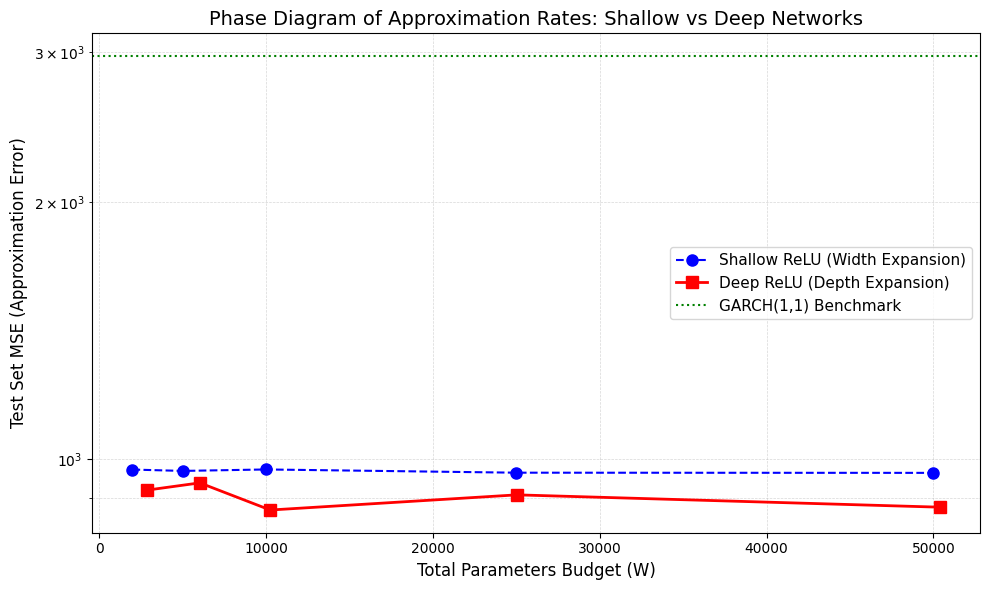

In [12]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Define tested parameter budget gradients
parameter_budgets = [2000, 5000, 10000, 25000, 50000]

shallow_mses = []
deep_mses = []
actual_w_shallow = []
actual_w_deep = []

criterion_test = nn.MSELoss()

for target_W in parameter_budgets:
    print(f"\n==================================================")
    print(f" Starting test for parameter budget W ~ {target_W}")
    print(f"==================================================")

    # ---------------- 1. Dynamically calculate network configuration ----------------
    shallow_width = int(target_W / (21 + 2))
    shallow_net = ShallowReLU(input_dim=21, hidden_dim=shallow_width)
    w_s = count_parameters(shallow_net)
    actual_w_shallow.append(w_s)

    deep_width = 32
    params_per_layer = deep_width * deep_width + deep_width
    num_layers = max(2, int((target_W - 737) / params_per_layer) + 2)
    deep_net = DeepReLU(input_dim=21, hidden_dim=deep_width, num_layers=num_layers)
    w_d = count_parameters(deep_net)
    actual_w_deep.append(w_d)

    print(f"Configuration set -> Shallow W: {w_s}, Deep W: {w_d} (Layers: {num_layers})")

    # ---------------- 2. Train and evaluate shallow network ----------------
    # epochs set to 300, patience set to 15 to speed up loop
    best_shallow, _, _ = train_model(
        shallow_net, f"Shallow (W={w_s})", train_loader, val_loader,
        epochs=300, lr=0.001, patience=15
    )
    best_shallow.eval()
    with torch.no_grad():
        s_test_preds = best_shallow(X_test_t)
        s_test_mse = criterion_test(s_test_preds, y_test_t).item()
    shallow_mses.append(s_test_mse)
    print(f">>> Shallow network Test Set MSE: {s_test_mse:.4f}")

    # ---------------- 3. Train and evaluate deep network ----------------
    best_deep, _, _ = train_model(
        deep_net, f"Deep (W={w_d})", train_loader, val_loader,
        epochs=300, lr=0.001, patience=15
    )
    best_deep.eval()
    with torch.no_grad():
        d_test_preds = best_deep(X_test_t)
        d_test_mse = criterion_test(d_test_preds, y_test_t).item()
    deep_mses.append(d_test_mse)
    print(f">>> Deep network Test Set MSE: {d_test_mse:.4f}")

# ---------------- 4. Plot Yarotsky approximation rate phase diagram ----------------
print("\nPlotting and saving approximation rate phase diagram...")
plt.figure(figsize=(10, 6))

# Plot shallow network curve
plt.plot(actual_w_shallow, shallow_mses, marker='o', markersize=8,
         label='Shallow ReLU (Width Expansion)', linestyle='--', color='blue')

# Plot deep network curve
plt.plot(actual_w_deep, deep_mses, marker='s', markersize=8,
         label='Deep ReLU (Depth Expansion)', linewidth=2, color='red')

# Add baseline reference line (GARCH)
plt.axhline(y=2969.88, color='green', linestyle=':', label='GARCH(1,1) Benchmark')

plt.xlabel('Total Parameters Budget (W)', fontsize=12)
plt.ylabel('Test Set MSE (Approximation Error)', fontsize=12)
plt.title('Phase Diagram of Approximation Rates: Shallow vs Deep Networks', fontsize=14)

# Use logarithmic coordinate system to clearly show exponential differences
plt.yscale('log')

plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Save chart
plt.tight_layout()
plt.savefig('phase_diagram.png', dpi=300)
print("Approximation rate phase diagram successfully saved as 'phase_diagram.png'!")